/home/hsherief/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


   theta  cos theta   h_stable_ana   h_stable_num
  0.0000     1.0000         0.7500         1.0000
  0.1500     0.9888         0.7963         1.0362
  0.2500     0.9689         0.9088         1.1183
  0.3398     0.9428         1.4142         1.4142
  0.5000     0.8776         1.3164         1.3164
  0.8000     0.6967         1.0451         1.0451
  1.0000     0.5403         0.8105         0.8105
  1.3000     0.2675         0.4012         0.4012
  1.5708     0.0000         0.0000            nan


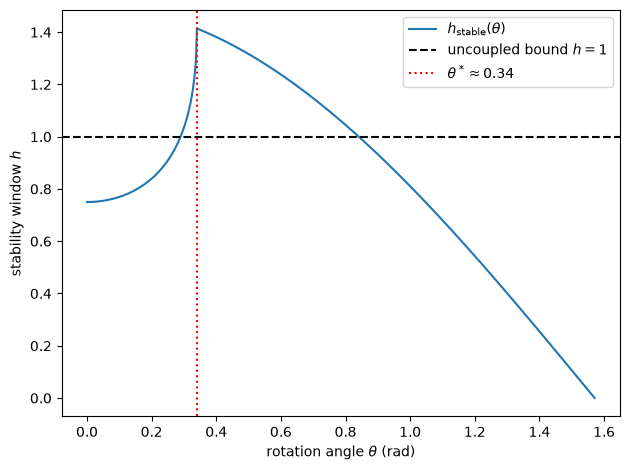

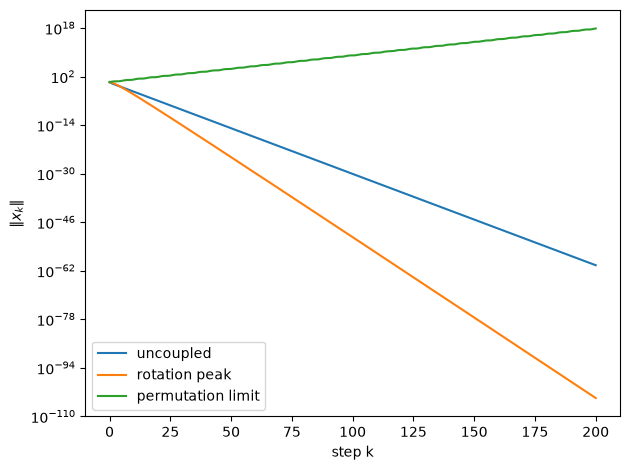

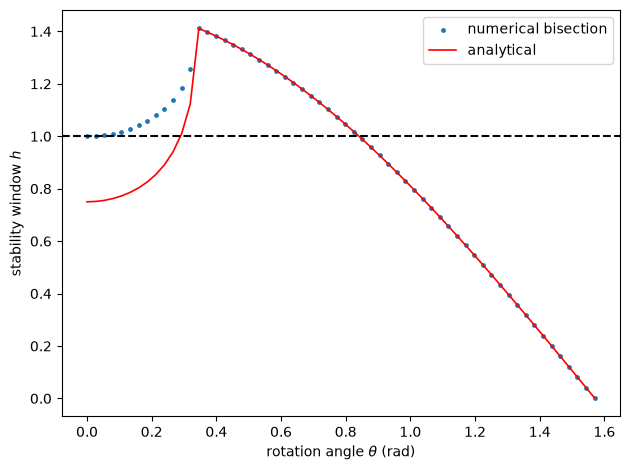

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = np.diag([-1.0, -2.0])

def R2(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def RA(theta):
    """Rotated two-block field R(theta) A."""
    return R2(theta) @ A

def rho_1step(theta, h):
    """Spectral radius of the frozen-theta forward Euler map."""
    M = np.eye(2) + h * RA(theta)
    return max(abs(np.linalg.eigvals(M)))

def h_stable_analytical(theta):
    """Closed-form stability window."""
    a, b = 1.0, 2.0
    mu = (a + b) * np.cos(theta) / 2.0
    ab = a * b
    if mu <= 0.0:
        return 0.0
    if mu * mu >= ab:
        return 2.0 * mu / (mu + np.sqrt(mu * mu - ab))**2
    return 2.0 * mu / ab

def h_stable_numerical(theta, h_lo=1e-6, h_hi=4.0, tol=1e-9):
    """Bisection on rho_1step(theta, h) = 1."""
    if rho_1step(theta, h_lo) >= 1.0:
        return 0.0
    if rho_1step(theta, h_hi) < 1.0:
        return np.inf
    while h_hi - h_lo > tol:
        h_mid = 0.5 * (h_lo + h_hi)
        if rho_1step(theta, h_mid) < 1.0:
            h_lo = h_mid
        else:
            h_hi = h_mid
    return 0.5 * (h_lo + h_hi)

# --- Table 1 / 4: analytical vs numerical -----------------------
print(f"{'theta':>8} {'cos theta':>10} {'h_stable_ana':>14} {'h_stable_num':>14}")
for theta in [0.0, 0.15, 0.25, np.arccos(2*np.sqrt(2)/3), 0.5, 0.8, 1.0, 1.3, np.pi/2]:
    h_a = h_stable_analytical(theta)
    h_n = h_stable_numerical(theta) if theta < np.pi/2 - 1e-12 else float('nan')
    print(f"{theta:8.4f} {np.cos(theta):10.4f} {h_a:14.4f} {h_n:14.4f}")

# --- Figure 1: h_stable(theta) ----------------------------------
thetas = np.linspace(0.0, np.pi/2 - 1e-6, 800)
hs = np.array([h_stable_analytical(t) for t in thetas])
plt.figure()
plt.plot(thetas, hs, label=r'$h_{\mathrm{stable}}(\theta)$')
plt.axhline(1.0, ls='--', c='k', label=r'uncoupled bound $h=1$')
plt.axvline(np.arccos(2*np.sqrt(2)/3), ls=':', c='r', label=r'$\theta^* \approx 0.34$')
plt.xlabel(r'rotation angle $\theta$ (rad)')
plt.ylabel(r'stability window $h$')
plt.legend(); plt.tight_layout(); plt.savefig('Fig1.tif', dpi=300)

# --- Figure 2: trajectory norms at h = 0.5 ----------------------
h = 0.5
N = 200
x0 = np.array([1.0, 1.0])

def run_frozen(theta, h, N, x0):
    x = x0.copy(); out = [x.copy()]
    M = np.eye(2) + h * RA(theta)
    for _ in range(N):
        x = M @ x
        out.append(x.copy())
    return np.array(out)

plt.figure()
for theta, name in [(0.0, 'uncoupled'),
                    (np.arccos(2*np.sqrt(2)/3), 'rotation peak'),
                    (np.pi/2, 'permutation limit')]:
    traj = run_frozen(theta, h, N, x0)
    plt.semilogy(np.arange(N+1), np.linalg.norm(traj, axis=1), label=name)
plt.xlabel('step k'); plt.ylabel(r'$\|x_k\|$')
plt.legend(); plt.tight_layout(); plt.savefig('Fig2.tif', dpi=300)

# --- Figure 3: verification scatter -----------------------------
plt.figure()
test_thetas = np.linspace(0.0, np.pi/2 - 1e-3, 60)
h_ana = np.array([h_stable_analytical(t) for t in test_thetas])
h_num = np.array([h_stable_numerical(t) for t in test_thetas])
plt.scatter(test_thetas, h_num, s=6, label='numerical bisection')
plt.plot(test_thetas, h_ana, c='r', lw=1.2, label='analytical')
plt.axhline(1.0, ls='--', c='k')
plt.xlabel(r'rotation angle $\theta$ (rad)')
plt.ylabel(r'stability window $h$')
plt.legend(); plt.tight_layout(); plt.savefig('Fig3.tif', dpi=300)

In [2]:
"""Geometric-algebra implementation of the rotor-coupled
flood--earthquake system in Cl(5,0)."""

import numpy as np

# --- Cl(5,0) multivector arithmetic ------------------------------------
N = 5
NUM_BLADES = 1 << N

def _popcount(x):
    return bin(x).count('1')

def _blade_sign(a, b):
    sign = 1
    for i in range(N):
        if (a >> i) & 1:
            lower_b = b & ((1 << i) - 1)
            if _popcount(lower_b) & 1:
                sign = -sign
    return sign

class MV:
    __slots__ = ('c',)
    def __init__(self, c=None):
        self.c = np.zeros(NUM_BLADES) if c is None else np.asarray(c, dtype=np.float64)

    @staticmethod
    def vector(v):
        m = MV()
        for i in range(N):
            m.c[1 << i] = v[i]
        return m

    @staticmethod
    def scalar(s):
        m = MV(); m.c[0] = s; return m

    def __add__(self, o):  return MV(self.c + o.c)
    def __sub__(self, o):  return MV(self.c - o.c)
    def __mul__(self, s):  return MV(self.c * s)
    __rmul__ = __mul__

    def gp(self, o):
        result = np.zeros(NUM_BLADES)
        nz_a = np.nonzero(self.c)[0]
        nz_b = np.nonzero(o.c)[0]
        for a in nz_a:
            for b in nz_b:
                s = _blade_sign(a, b)
                result[a ^ b] += s * self.c[a] * o.c[b]
        return MV(result)

    def reverse(self):
        result = np.zeros(NUM_BLADES)
        for idx in range(NUM_BLADES):
            k = _popcount(idx)
            result[idx] = ((-1) ** (k * (k - 1) // 2)) * self.c[idx]
        return MV(result)

    def sandwich(self, o):
        return self.gp(o).gp(self.reverse())

    def vector_part(self):
        out = np.zeros(N)
        for i in range(N):
            out[i] = self.c[1 << i]
        return out

# --- Rotor R(theta) = exp(-B theta / 2) for B = e_0^e_2 + e_1^e_3 -----
def rotor(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    m = MV()
    m.c[0] = c * c
    m.c[(1 << 0) | (1 << 2)] = -c * s          # <-- flipped sign
    m.c[(1 << 1) | (1 << 3)] = -c * s          # <-- flipped sign
    m.c[(1 << 0) | (1 << 1) | (1 << 2) | (1 << 3)] = -s * s
    return m

def apply_rotation(theta, state_5):
    R = rotor(theta)
    v = MV.vector(state_5)
    return R.sandwich(v).vector_part()

# --- Nine-component rotor-coupled modal field ---------------------------
ETA, V1, V2, U1, U3, W1, W3, THETA, OMEGA = range(9)

def physical_modal_terms(state):
    eta, v1, v2, u1, u3, w1, w3, theta = state[:8]
    depth = 1.0 + eta
    rotated = apply_rotation(theta, np.array([u1, u3, eta, v1, v2]))
    rotated_u3, rotated_eta = rotated[1], rotated[2]

    gravity, density = 1.0, 1.0
    k1, k2, k3 = 0.78, 0.46, 0.62
    lame_lambda, shear_mu = 0.42, 0.26
    d1, d2 = 0.060, 0.045
    seismic_damping = 0.055
    bed_to_flood = 0.22
    lambda_mode = 0.34

    d_eta = -k1 * v1 - k2 * v2
    d_v1 = gravity * k1 * eta + bed_to_flood * gravity * depth * k1 * rotated_u3 - d1 * v1
    d_v2 = gravity * k2 * eta - d2 * v2

    wn_sq = k1**2 + k3**2
    long_mod = lame_lambda + 2.0 * shear_mu
    S11 = long_mod * k1**2 + shear_mu * wn_sq
    S33 = long_mod * k3**2 + shear_mu * wn_sq
    S13 = long_mod * k1 * k3
    flood_force = lambda_mode * gravity * k1 * rotated_eta

    acc_u1 = (-S11 * u1 - S13 * u3) / density - seismic_damping * w1
    acc_u3 = (-S13 * u1 - S33 * u3 + flood_force) / density - seismic_damping * w3

    return np.array((d_eta, d_v1, d_v2, w1, w3, acc_u1, acc_u3))

def rotation_acceleration(state, base_field):
    eta, v1, v2, u1, u3, w1, w3, theta, omega = state
    phi = np.array([u1, u3, eta, v1, v2])
    phi_dot = np.array([w1, w3, base_field[0], base_field[1], base_field[2]])

    # Directional derivative of Phi_dot along the flow
    dt = 1.0e-5
    probe = state.copy()
    probe[:7] += dt * base_field
    probe[THETA] += dt * omega
    probe_field = physical_modal_terms(probe)
    probe_phi_dot = np.array([probe_field[3], probe_field[4],
                              probe_field[0], probe_field[1], probe_field[2]])
    phi_ddot = (probe_phi_dot - phi_dot) / dt

    # Torque = -Phi_ddot . (B . Phi) where B acts on the modal vector
    B_action = np.array([-phi[2], -phi[3], phi[0], phi[1], 0.0])
    numerator = 2.0 * omega * float(phi @ phi_dot) + float(phi_ddot @ B_action)
    inertia_floor = 0.28
    return -numerator / (float(phi @ phi) + inertia_floor)

def rotor_coupled_field(state):
    base = physical_modal_terms(state)
    alpha = rotation_acceleration(state, base)
    eta, v1, _v2, u1, u3, w1, w3, _theta, omega = state

    M = 0.085  # modal mass ratio
    d_eta = base[0] - M * (alpha * u1 + 2.0 * omega * w1 - omega**2 * eta)
    d_v1 = base[1] - M * (alpha * u3 + 2.0 * omega * w3 - omega**2 * v1)
    d_v2 = base[2]
    acc_u1 = base[5] + M * (alpha * eta + 2.0 * omega * d_eta - omega**2 * u1)
    acc_u3 = base[6] + M * (alpha * v1 + 2.0 * omega * d_v1 - omega**2 * u3)

    return np.array((d_eta, d_v1, d_v2, w1, w3, acc_u1, acc_u3, omega, alpha))

def simulate(n_steps=2400, dt=0.012, theta_0=0.7854, omega_0=0.18):
    states = np.empty((n_steps + 1, 9))
    states[0] = (-0.28, 0.10, -0.055, 0.08, -0.22, 0.025, 0.10, theta_0, omega_0)
    for k in range(n_steps):
        states[k + 1] = states[k] + dt * rotor_coupled_field(states[k])
    return states

if __name__ == '__main__':
    # Verify the rotor against the closed-form matrix rotation
    theta = 0.7
    v = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
    v_rot = apply_rotation(theta, v)
    assert abs(np.dot(v_rot, v_rot) - np.dot(v, v)) < 1e-12
    expected = np.array([
        np.cos(theta) * v[0] - np.sin(theta) * v[2],
        np.cos(theta) * v[1] - np.sin(theta) * v[3],
        np.sin(theta) * v[0] + np.cos(theta) * v[2],
        np.sin(theta) * v[1] + np.cos(theta) * v[3],
        v[4],
    ])
    assert np.allclose(v_rot, expected)

    # Integrate the coupled system
    states = simulate()
    print(f"Final state: theta = {states[-1, THETA]:.4f}, "
          f"omega = {states[-1, OMEGA]:.4f}, "
          f"coupling C = sin^2(theta) = {np.sin(states[-1, THETA])**2:.4f}")

Final state: theta = 12.0263, omega = 0.2746, coupling C = sin^2(theta) = 0.2644
